# Análisis de Canasta de Mercado
## Apriori + ECLAT con segmentación y visualizaciones
**Minería de Datos**

---
## 1. Carga y exploración de datos

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules
from itertools import combinations
import warnings, os
warnings.filterwarnings('ignore')

# Crear carpeta de imágenes y auto-guardar cada gráfica
os.makedirs('imagenes', exist_ok=True)
_fig_counter = [0]
_original_show = plt.show
def _autosave_show(*args, **kwargs):
    for fn in plt.get_fignums():
        _fig_counter[0] += 1
        plt.figure(fn).savefig(f'imagenes/grafica_{_fig_counter[0]:02d}.png',
                               bbox_inches='tight', dpi=150)
    _original_show(*args, **kwargs)
plt.show = _autosave_show

# Estilo general
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
sns.set_theme(style='whitegrid', palette='muted')

df = pd.read_excel('mercado_SB.xlsx')
print(f'Filas: {df.shape[0]}, Columnas: {df.shape[1]}')
df.head()


Filas: 100, Columnas: 35


,edad,estrato_nse,canal_compra,gasto,arroz,leche,huevos,pan,pollo,carne_res,...,cuadernos,lapiceros,limpiador_multiuso,ambientador,esponjas,velas,pilas,bolsas_basura,toallas_papel,enjuague_bucal
0,38,E1,Tienda,1349958,0,1,0,0,0,1,...,1,0,0,0,0,0,1,0,0,1
1,34,E5,Hard Discount,346122,1,1,1,1,1,0,...,0,1,1,1,0,1,0,1,0,0
2,38,E3,Supermercado,190309,0,0,0,1,0,1,...,0,1,1,0,0,1,1,0,0,0
3,26,E4,Hard Discount,708253,0,1,0,1,1,1,...,0,0,1,1,1,0,0,0,1,0
4,42,E2,Supermercado,1383329,1,0,1,0,1,0,...,0,1,0,1,1,0,1,0,0,0


In [2]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 35 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   edad                100 non-null    int64
 1   estrato_nse         100 non-null    str  
 2   canal_compra        100 non-null    str  
 3   gasto               100 non-null    int64
 4   arroz               100 non-null    int64
 5   leche               100 non-null    int64
 6   huevos              100 non-null    int64
 7   pan                 100 non-null    int64
 8   pollo               100 non-null    int64
 9   carne_res           100 non-null    int64
 10  cafe                100 non-null    int64
 11  azucar              100 non-null    int64
 12  aceite              100 non-null    int64
 13  galletas            100 non-null    int64
 14  detergente          100 non-null    int64
 15  jabon               100 non-null    int64
 16  lapices             100 non-null    int64
 17  papel_hig

,edad,gasto,arroz,leche,huevos,pan,pollo,carne_res,cafe,azucar,...,cuadernos,lapiceros,limpiador_multiuso,ambientador,esponjas,velas,pilas,bolsas_basura,toallas_papel,enjuague_bucal
count,100.000000,1.000000e+02,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,...,100.000000,100.000000,100.000000,100.00,100.000000,100.000000,100.000000,100.000000,100.000000,100.00000
mean,43.120000,8.135149e+05,0.710000,0.590000,0.580000,0.560000,0.500000,0.470000,0.600000,0.600000,...,0.400000,0.490000,0.470000,0.55,0.460000,0.510000,0.420000,0.490000,0.520000,0.43000
std,14.966819,4.094165e+05,0.456048,0.494311,0.496045,0.498888,0.502519,0.501614,0.492366,0.492366,...,0.492366,0.502418,0.501614,0.50,0.500908,0.502418,0.496045,0.502418,0.502117,0.49757
min,18.000000,1.151580e+05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,30.000000,4.586180e+05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,42.500000,8.128410e+05,1.000000,1.000000,1.000000,1.000000,0.500000,0.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,1.00,0.000000,1.000000,0.000000,0.000000,1.000000,0.00000
75%,57.000000,1.146351e+06,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.00,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000
max,69.000000,1.492935e+06,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.00,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


---
## 2. Análisis Exploratorio (EDA)

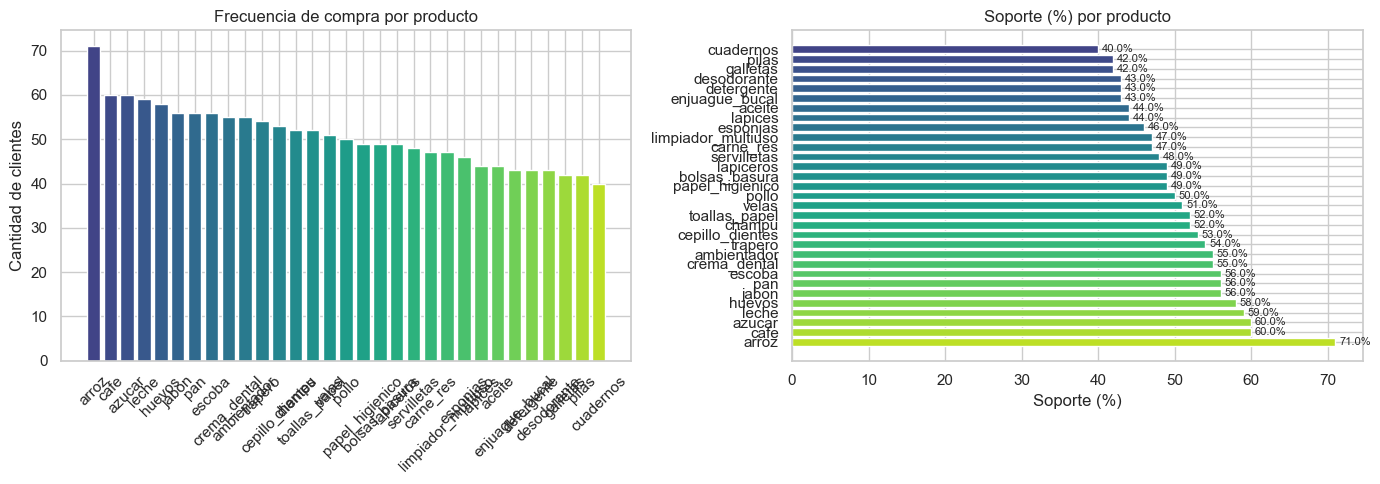

In [26]:
# Columnas de productos
cols_demo = ['edad', 'estrato_nse', 'canal_compra', 'gasto']
productos = df.drop(columns=cols_demo)
nombres_productos = list(productos.columns)

# --- Frecuencia de compra por producto ---
frecuencia = productos.sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barras
colors = cm.viridis(np.linspace(0.2, 0.9, len(frecuencia)))
axes[0].bar(frecuencia.index, frecuencia.values, color=colors)
axes[0].set_title('Frecuencia de compra por producto')
axes[0].set_ylabel('Cantidad de clientes')
axes[0].tick_params(axis='x', rotation=45)

# Soporte (proporción)
soporte = (frecuencia / len(df) * 100)
axes[1].barh(soporte.index, soporte.values, color=colors[::-1])
axes[1].set_title('Soporte (%) por producto')
axes[1].set_xlabel('Soporte (%)')
for i, v in enumerate(soporte.values):
    axes[1].text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=8)

plt.tight_layout()
plt.show()

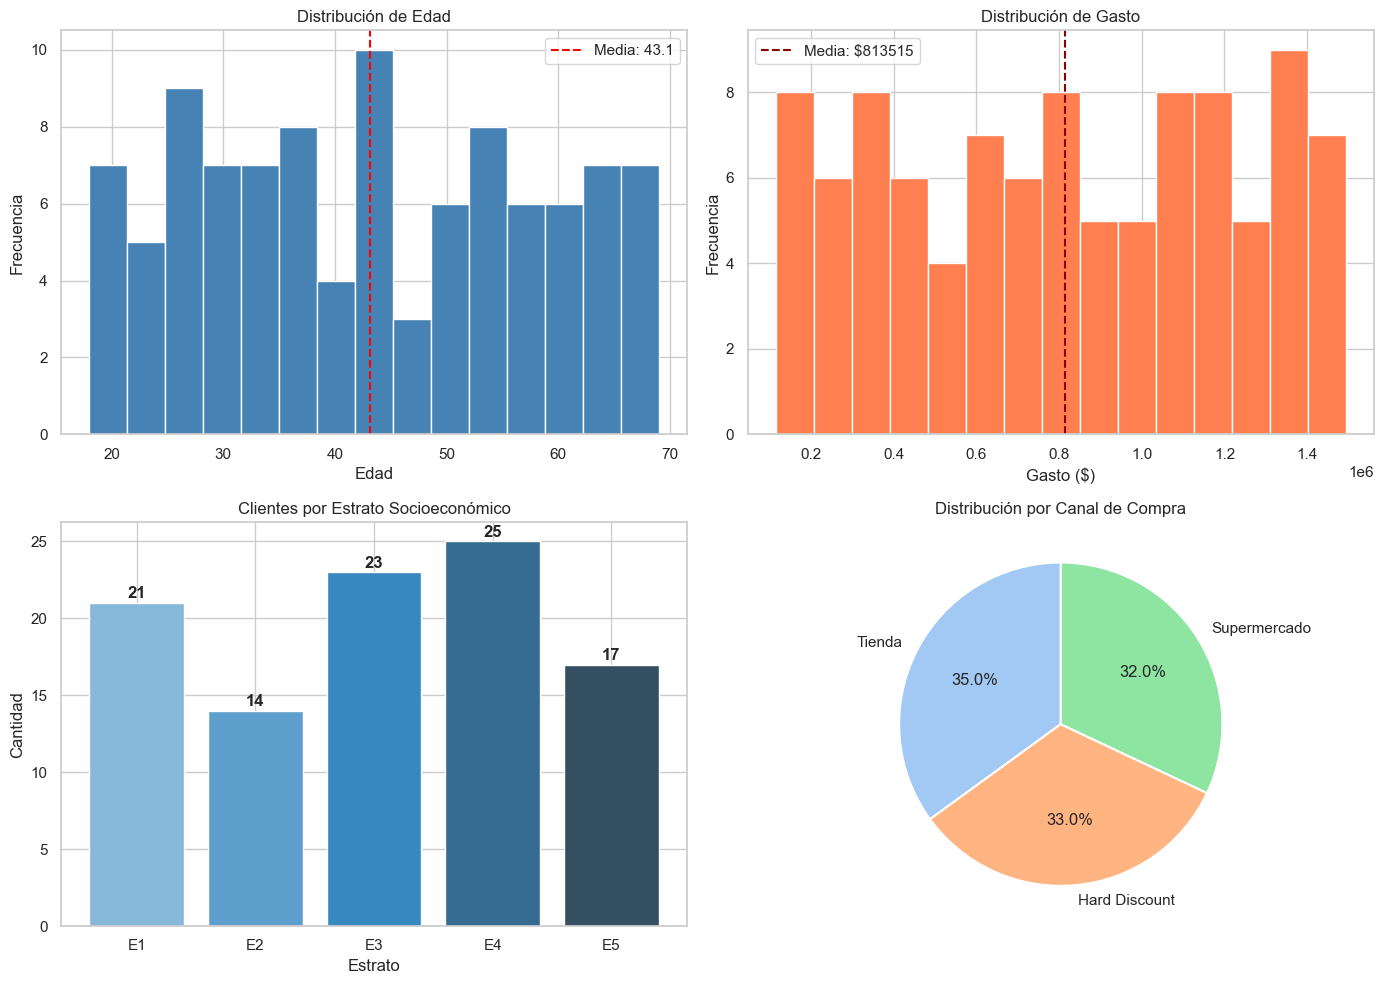

In [27]:
# --- Variables demográficas ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distribución de edad
axes[0, 0].hist(df['edad'], bins=15, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Distribución de Edad')
axes[0, 0].set_xlabel('Edad')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].axvline(df['edad'].mean(), color='red', linestyle='--', label=f'Media: {df["edad"].mean():.1f}')
axes[0, 0].legend()

# Distribución de gasto
axes[0, 1].hist(df['gasto'], bins=15, color='coral', edgecolor='white')
axes[0, 1].set_title('Distribución de Gasto')
axes[0, 1].set_xlabel('Gasto ($)')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].axvline(df['gasto'].mean(), color='darkred', linestyle='--', label=f'Media: ${df["gasto"].mean():.0f}')
axes[0, 1].legend()

# Distribución por estrato
estrato_counts = df['estrato_nse'].value_counts().sort_index()
axes[1, 0].bar(estrato_counts.index, estrato_counts.values, color=sns.color_palette('Blues_d', len(estrato_counts)))
axes[1, 0].set_title('Clientes por Estrato Socioeconómico')
axes[1, 0].set_xlabel('Estrato')
axes[1, 0].set_ylabel('Cantidad')
for i, v in enumerate(estrato_counts.values):
    axes[1, 0].text(i, v + 0.3, str(v), ha='center', fontweight='bold')

# Canal de compra (pie)
canal_counts = df['canal_compra'].value_counts()
axes[1, 1].pie(canal_counts.values, labels=canal_counts.index, autopct='%1.1f%%',
               colors=sns.color_palette('pastel'), startangle=90,
               wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1, 1].set_title('Distribución por Canal de Compra')

plt.tight_layout()
plt.show()

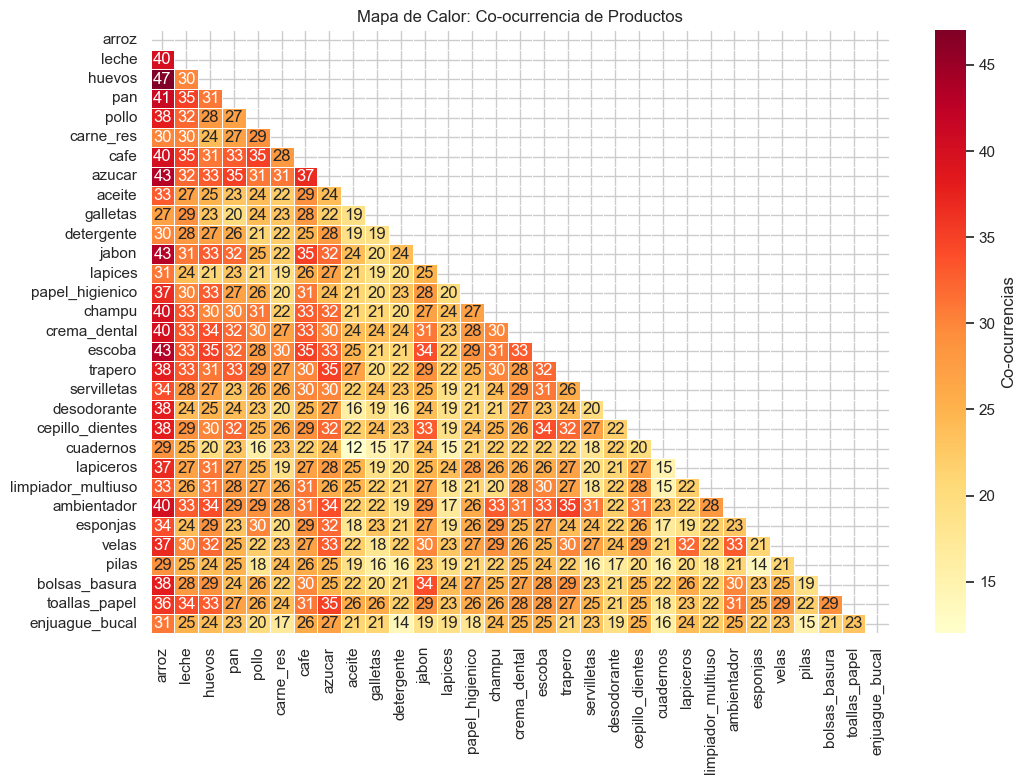

In [28]:
# --- Heatmap de co-ocurrencia de productos ---
co_matrix = productos.T.dot(productos)
co_arr = co_matrix.to_numpy().copy()
np.fill_diagonal(co_arr, 0)
co_matrix = pd.DataFrame(co_arr, index=co_matrix.index, columns=co_matrix.columns)

plt.figure(figsize=(11, 8))
mask = np.zeros_like(co_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(co_matrix, annot=True, fmt='d', cmap='YlOrRd',
            mask=mask, linewidths=0.5, cbar_kws={'label': 'Co-ocurrencias'})
plt.title('Mapa de Calor: Co-ocurrencia de Productos')
plt.tight_layout()
plt.show()


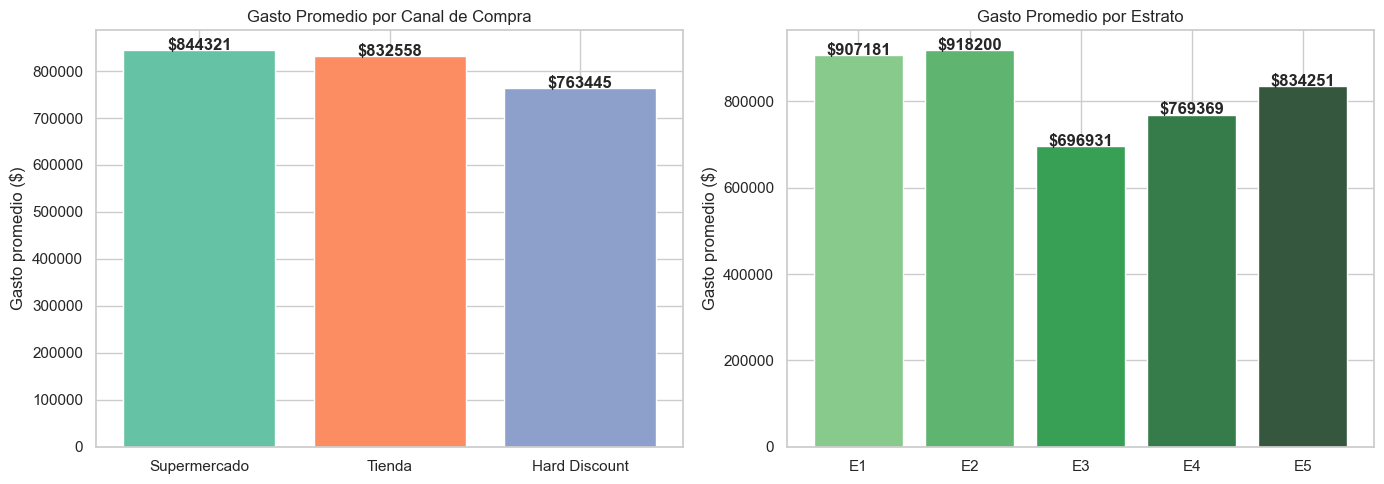

In [29]:
# --- Gasto promedio por canal y estrato ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

gasto_canal = df.groupby('canal_compra')['gasto'].mean().sort_values(ascending=False)
axes[0].bar(gasto_canal.index, gasto_canal.values, color=sns.color_palette('Set2', len(gasto_canal)))
axes[0].set_title('Gasto Promedio por Canal de Compra')
axes[0].set_ylabel('Gasto promedio ($)')
for i, v in enumerate(gasto_canal.values):
    axes[0].text(i, v + 100, f'${v:.0f}', ha='center', fontweight='bold')

gasto_estrato = df.groupby('estrato_nse')['gasto'].mean().sort_index()
axes[1].bar(gasto_estrato.index, gasto_estrato.values, color=sns.color_palette('Greens_d', len(gasto_estrato)))
axes[1].set_title('Gasto Promedio por Estrato')
axes[1].set_ylabel('Gasto promedio ($)')
for i, v in enumerate(gasto_estrato.values):
    axes[1].text(i, v + 100, f'${v:.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

---
## 3. Algoritmo APRIORI

In [7]:
# Apriori general
frequent_itemsets = apriori(productos.astype(bool), min_support=0.2, use_colnames=True)
rules = association_rules(frequent_itemsets, metric='lift', min_threshold=1)
rules['affinity'] = rules['confidence'] * rules['lift']
rules['score'] = 0.4 * rules['support'] + 0.3 * rules['confidence'] + 0.3 * rules['lift']
rules['antecedents_str'] = rules['antecedents'].apply(lambda x: ', '.join(sorted(x)))
rules['consequents_str'] = rules['consequents'].apply(lambda x: ', '.join(sorted(x)))
rules['rule'] = rules['antecedents_str'] + ' → ' + rules['consequents_str']

print(f'Reglas encontradas: {len(rules)}')
rules.sort_values('affinity', ascending=False).head(10)[['rule', 'support', 'confidence', 'lift', 'affinity']].reset_index(drop=True)

Reglas encontradas: 2226


,rule,support,confidence,lift,affinity
0,"desodorante, papel_higienico → arroz",0.20,0.952381,1.341382,1.277506
1,"desodorante, lapiceros → arroz",0.20,0.952381,1.341382,1.277506
2,"champu, desodorante → arroz",0.20,0.952381,1.341382,1.277506
3,"crema_dental, desodorante → arroz",0.25,0.925926,1.304121,1.207519
4,"desodorante, huevos → arroz",0.23,0.920000,1.295775,1.192113
5,"servilletas, trapero → ambientador",0.21,0.807692,1.468531,1.186122
6,"carne_res, limpiador_multiuso → pollo",0.20,0.769231,1.538462,1.183432
7,"esponjas, toallas_papel → azucar",0.21,0.840000,1.400000,1.176000
8,"desodorante, escoba → arroz",0.21,0.913043,1.285977,1.174153
9,"cafe, escoba, jabon → arroz",0.21,0.913043,1.285977,1.174153


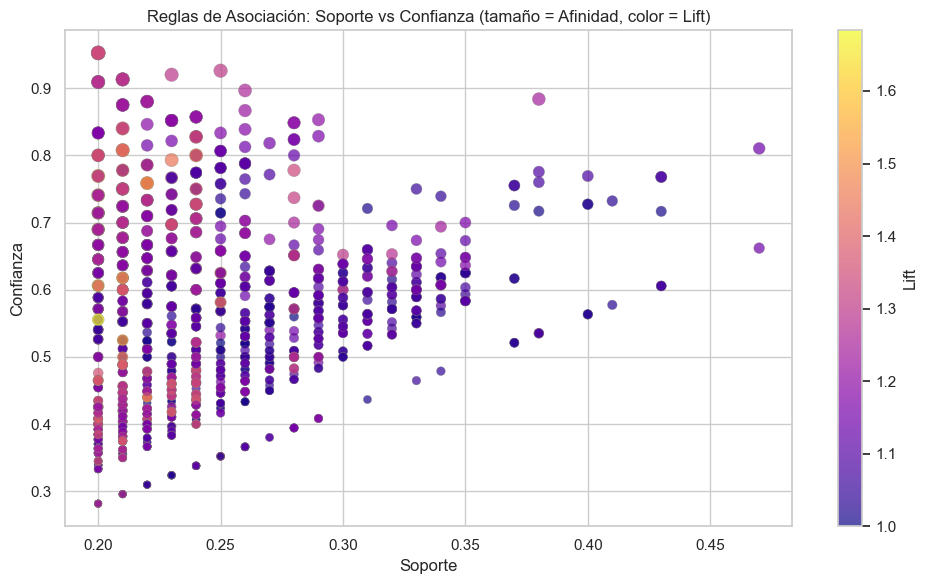

In [30]:
# --- Scatter: Soporte vs Confianza coloreado por Lift ---
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    rules['support'], rules['confidence'],
    c=rules['lift'], cmap='plasma', alpha=0.7,
    s=rules['affinity'] * 80, edgecolors='gray', linewidths=0.3
)
plt.colorbar(scatter, label='Lift')
plt.xlabel('Soporte')
plt.ylabel('Confianza')
plt.title('Reglas de Asociación: Soporte vs Confianza (tamaño = Afinidad, color = Lift)')
plt.tight_layout()
plt.show()

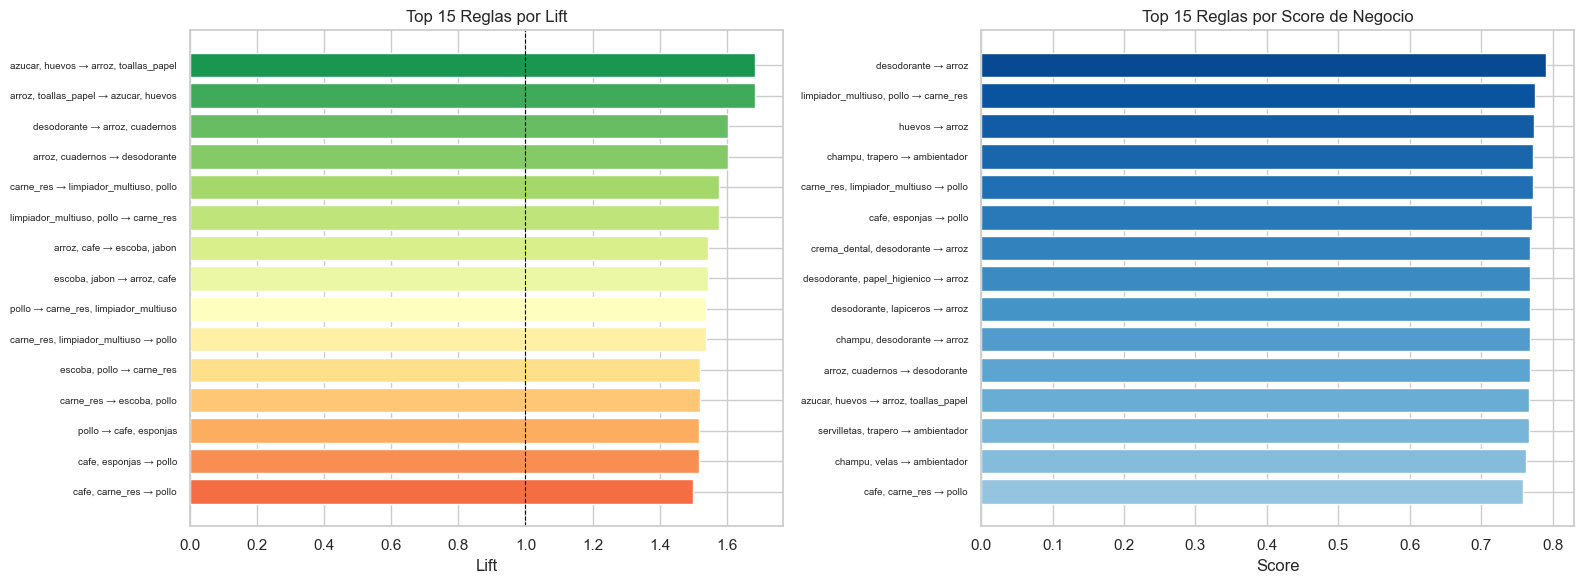

In [31]:
# --- Top 15 reglas por Lift ---
top_rules = rules.sort_values('lift', ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top por Lift
colors_lift = cm.RdYlGn(np.linspace(0.2, 0.9, 15))
axes[0].barh(top_rules['rule'][::-1], top_rules['lift'][::-1], color=colors_lift)
axes[0].set_title('Top 15 Reglas por Lift')
axes[0].set_xlabel('Lift')
axes[0].tick_params(axis='y', labelsize=7)
axes[0].axvline(1, color='black', linestyle='--', linewidth=0.8)

# Top por Score de negocio
top_score = rules.sort_values('score', ascending=False).head(15)
colors_score = cm.Blues(np.linspace(0.4, 0.9, 15))
axes[1].barh(top_score['rule'][::-1], top_score['score'][::-1], color=colors_score)
axes[1].set_title('Top 15 Reglas por Score de Negocio')
axes[1].set_xlabel('Score')
axes[1].tick_params(axis='y', labelsize=7)

plt.tight_layout()
plt.show()

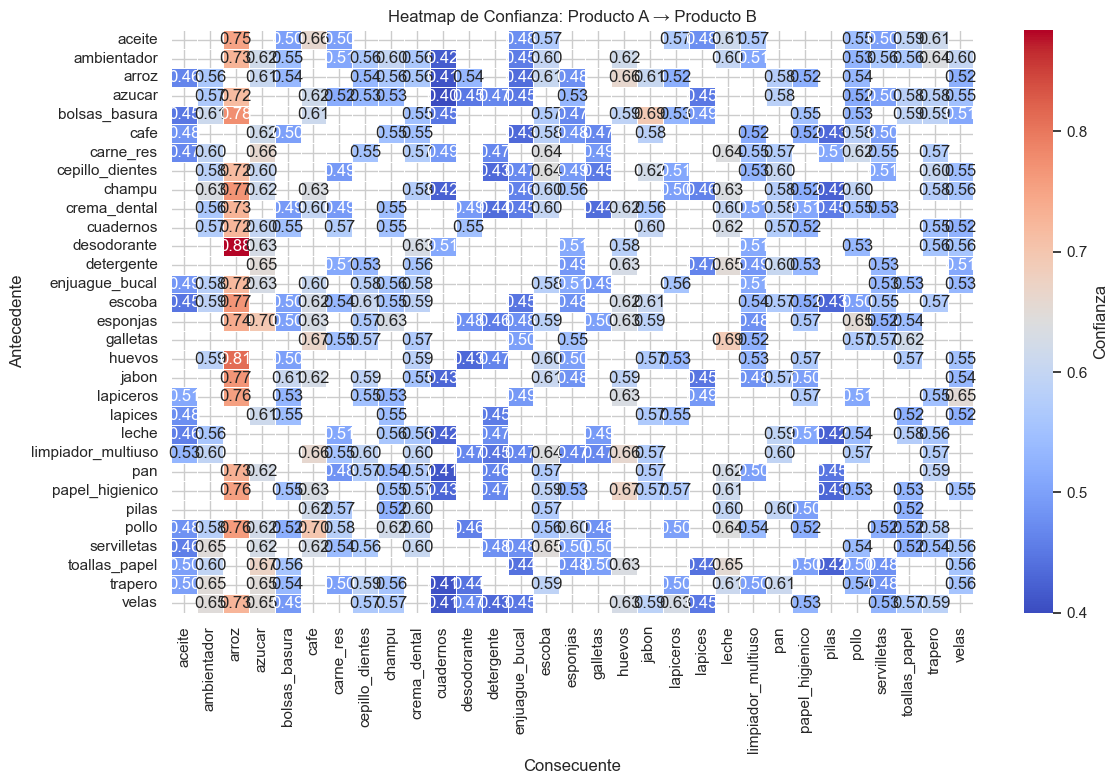

In [32]:
# --- Heatmap de Confianza: antecedente vs consecuente (itemsets de 1 elemento) ---
rules_simple = rules[
    (rules['antecedents'].apply(len) == 1) &
    (rules['consequents'].apply(len) == 1)
].copy()

conf_matrix = rules_simple.pivot_table(
    index='antecedents_str', columns='consequents_str', values='confidence', aggfunc='max'
)

plt.figure(figsize=(12, 8))
sns.heatmap(conf_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, cbar_kws={'label': 'Confianza'})
plt.title('Heatmap de Confianza: Producto A → Producto B')
plt.xlabel('Consecuente')
plt.ylabel('Antecedente')
plt.tight_layout()
plt.show()

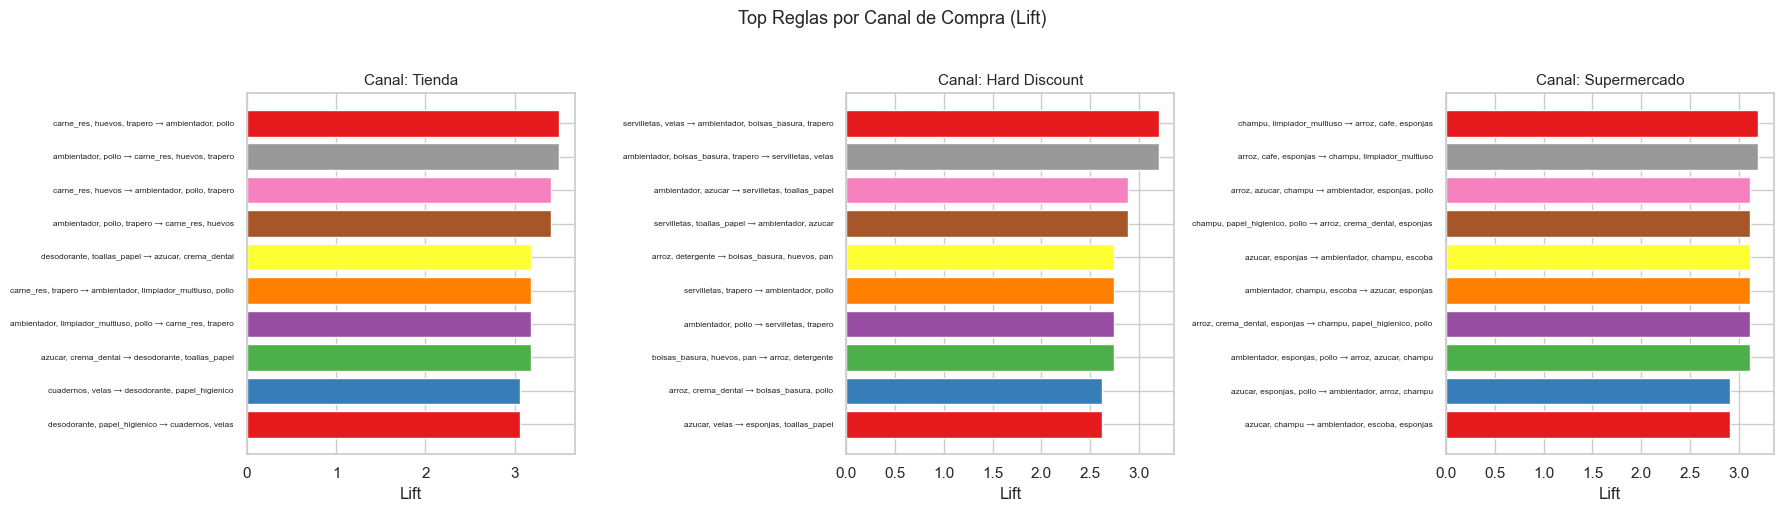

In [33]:
# --- Apriori por canal de compra ---
canales = df['canal_compra'].unique()
fig, axes = plt.subplots(1, len(canales), figsize=(6 * len(canales), 5))
if len(canales) == 1:
    axes = [axes]

for ax, canal in zip(axes, canales):
    subset = df[df['canal_compra'] == canal].drop(columns=cols_demo).astype(bool)
    if len(subset) < 5:
        continue
    try:
        fi = apriori(subset, min_support=0.2, use_colnames=True)
        r = association_rules(fi, metric='lift', min_threshold=1)
        top = r.sort_values('lift', ascending=False).head(10)
        top['rule'] = top['antecedents'].apply(lambda x: ', '.join(sorted(x))) + ' → ' + \
                      top['consequents'].apply(lambda x: ', '.join(sorted(x)))
        ax.barh(top['rule'][::-1], top['lift'][::-1], color=sns.color_palette('Set1', len(top)))
        ax.set_title(f'Canal: {canal}', fontsize=11)
        ax.set_xlabel('Lift')
        ax.tick_params(axis='y', labelsize=6)
    except Exception as e:
        ax.set_title(f'{canal}\n(sin reglas)')

plt.suptitle('Top Reglas por Canal de Compra (Lift)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 4. Algoritmo ECLAT

In [12]:
# ECLAT general con TID-lists
transactions = []
for _, row in productos.iterrows():
    trans = list(productos.columns[row == 1])
    transactions.append(trans)

tid_lists = {}
for i, trans in enumerate(transactions):
    for item in trans:
        tid_lists.setdefault(item, set()).add(i)

n = len(transactions)
min_support = 0.2
frequent_itemsets_eclat = []
items = list(tid_lists.keys())

for size in range(1, 4):
    for combo in combinations(items, size):
        tids = tid_lists[combo[0]].copy()
        for item in combo[1:]:
            tids = tids.intersection(tid_lists[item])
        support = len(tids) / n
        if support >= min_support:
            frequent_itemsets_eclat.append({'itemset': combo, 'support': round(support, 4), 'size': size})

freq_df = pd.DataFrame(frequent_itemsets_eclat)
print(f'Itemsets frecuentes encontrados: {len(freq_df)}')
freq_df.sort_values('support', ascending=False).head(15)

Itemsets frecuentes encontrados: 774


,itemset,support,size
11,"(arroz,)",0.71,1
2,"(cafe,)",0.60,1
26,"(azucar,)",0.60,1
0,"(leche,)",0.59,1
12,"(huevos,)",0.58,1
28,"(escoba,)",0.56,1
15,"(jabon,)",0.56,1
13,"(pan,)",0.56,1
6,"(crema_dental,)",0.55,1
23,"(ambientador,)",0.55,1


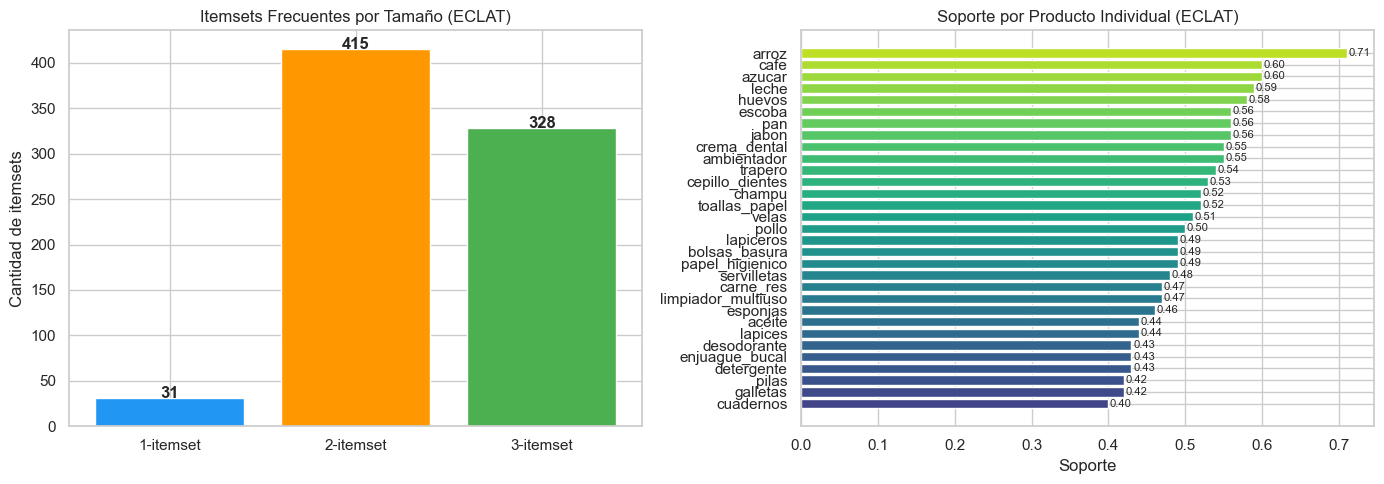

In [34]:
# --- Distribución de itemsets por tamaño ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

size_counts = freq_df['size'].value_counts().sort_index()
labels = {1: '1-itemset', 2: '2-itemset', 3: '3-itemset'}
axes[0].bar([labels.get(k, str(k)) for k in size_counts.index], size_counts.values,
            color=['#2196F3', '#FF9800', '#4CAF50'])
axes[0].set_title('Itemsets Frecuentes por Tamaño (ECLAT)')
axes[0].set_ylabel('Cantidad de itemsets')
for i, v in enumerate(size_counts.values):
    axes[0].text(i, v + 0.3, str(v), ha='center', fontweight='bold')

# Top 15 itemsets de 1 elemento por soporte
singles = freq_df[freq_df['size'] == 1].copy()
singles['label'] = singles['itemset'].apply(lambda x: x[0])
singles = singles.sort_values('support', ascending=True)
axes[1].barh(singles['label'], singles['support'],
             color=cm.viridis(np.linspace(0.2, 0.9, len(singles))))
axes[1].set_title('Soporte por Producto Individual (ECLAT)')
axes[1].set_xlabel('Soporte')
for i, v in enumerate(singles['support'].values):
    axes[1].text(v + 0.002, i, f'{v:.2f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

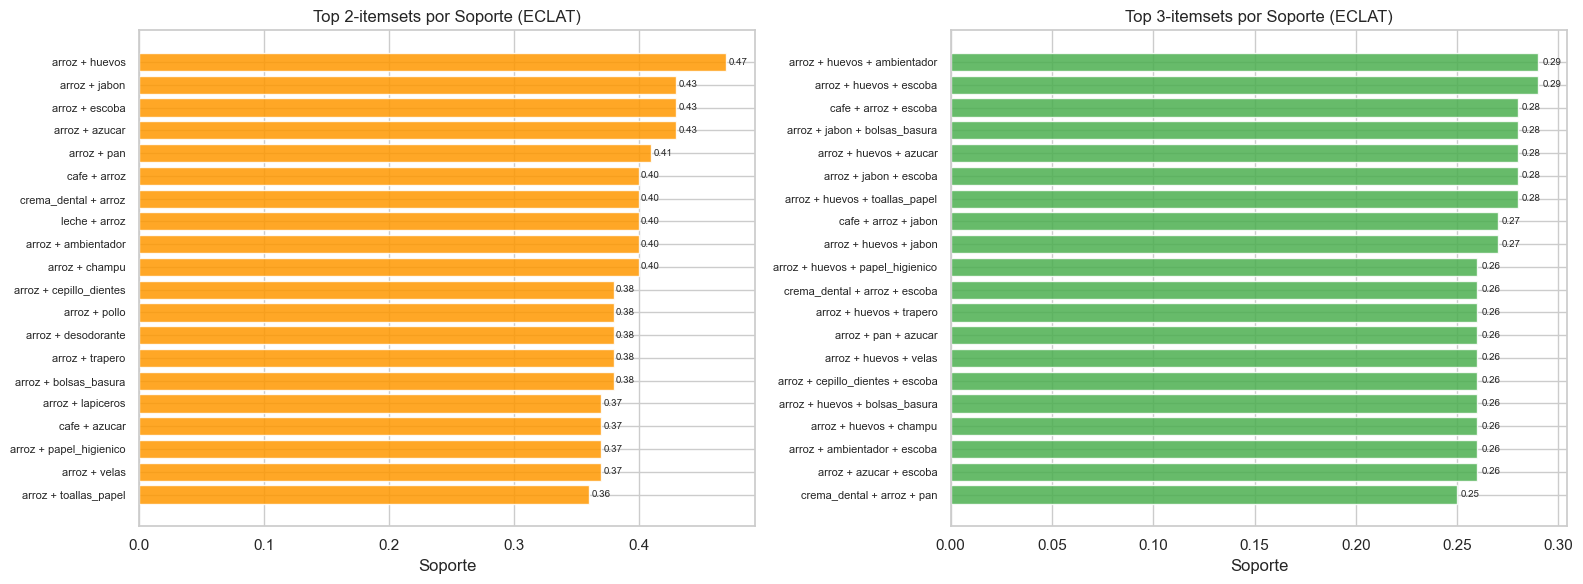

In [35]:
# --- Top 20 itemsets de 2 y 3 elementos ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, size, color in zip(axes, [2, 3], ['#FF9800', '#4CAF50']):
    sub = freq_df[freq_df['size'] == size].sort_values('support', ascending=False).head(20)
    sub['label'] = sub['itemset'].apply(lambda x: ' + '.join(x))
    sub = sub.sort_values('support', ascending=True)
    ax.barh(sub['label'], sub['support'], color=color, alpha=0.85)
    ax.set_title(f'Top {size}-itemsets por Soporte (ECLAT)')
    ax.set_xlabel('Soporte')
    ax.tick_params(axis='y', labelsize=8)
    for i, v in enumerate(sub['support'].values):
        ax.text(v + 0.002, i, f'{v:.2f}', va='center', fontsize=7)

plt.tight_layout()
plt.show()

---
## 5. Segmentación por Estrato Socioeconómico

In [15]:
def eclat_segmento(data, min_support=0.2, max_size=3):
    prods = data.drop(columns=cols_demo, errors='ignore')
    transactions = [list(prods.columns[row == 1]) for _, row in prods.iterrows()]
    tid_lists = {}
    for i, trans in enumerate(transactions):
        for item in trans:
            tid_lists.setdefault(item, set()).add(i)
    n = len(transactions)
    results = []
    for size in range(1, max_size + 1):
        for combo in combinations(tid_lists.keys(), size):
            tids = tid_lists[combo[0]].copy()
            for item in combo[1:]:
                tids = tids.intersection(tid_lists[item])
            support = len(tids) / n
            if support >= min_support:
                results.append({'itemset': list(combo), 'support': round(support, 4)})
    return pd.DataFrame(results)

# Calcular por estrato
resultados_estrato = {}
for estrato in sorted(df['estrato_nse'].unique()):
    subset = df[df['estrato_nse'] == estrato]
    resultados_estrato[estrato] = eclat_segmento(subset)

print('Segmentación por estrato completa.')

Segmentación por estrato completa.


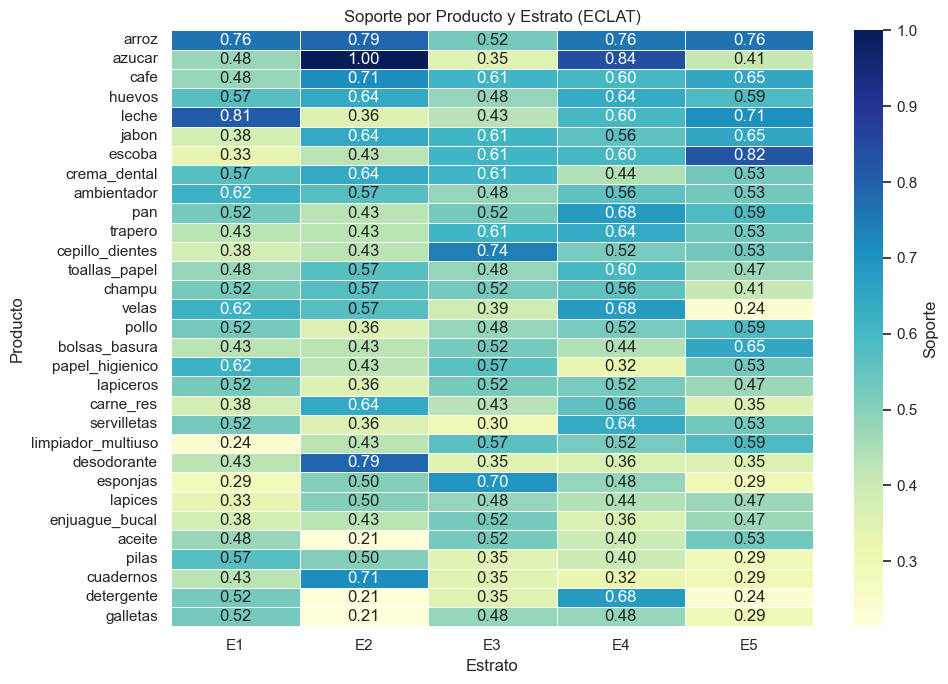

In [36]:
# --- Heatmap: soporte por producto × estrato ---
data_heat = {}
for estrato, res in resultados_estrato.items():
    singles = res[res['itemset'].apply(len) == 1]
    data_heat[estrato] = {row['itemset'][0]: row['support'] for _, row in singles.iterrows()}

heat_df = pd.DataFrame(data_heat).fillna(0)
heat_df = heat_df.loc[heat_df.mean(axis=1).sort_values(ascending=False).index]

plt.figure(figsize=(10, 7))
sns.heatmap(heat_df, annot=True, fmt='.2f', cmap='YlGnBu',
            linewidths=0.5, cbar_kws={'label': 'Soporte'})
plt.title('Soporte por Producto y Estrato (ECLAT)')
plt.xlabel('Estrato')
plt.ylabel('Producto')
plt.tight_layout()
plt.show()

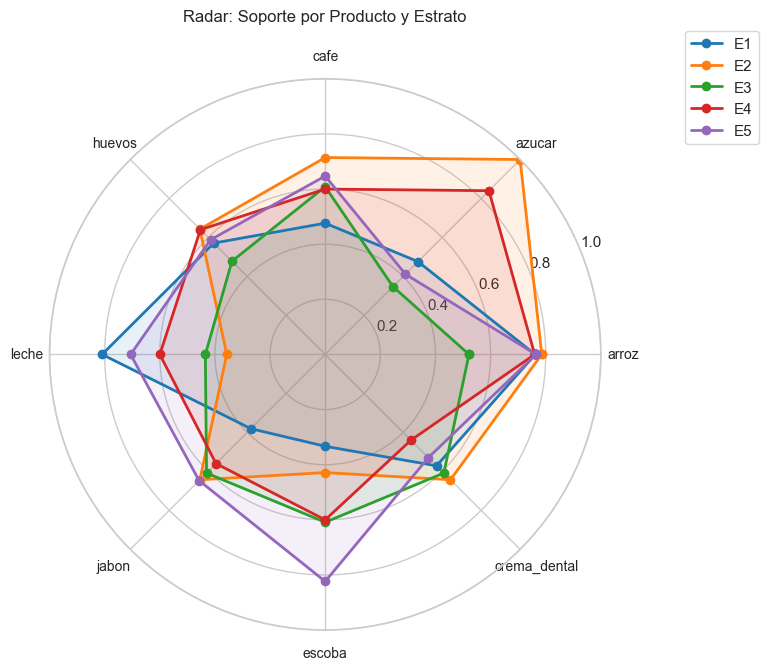

In [37]:
# --- Radar chart: top 6 productos por estrato ---
from matplotlib.patches import FancyArrowPatch
import math

top_prods = heat_df.mean(axis=1).nlargest(8).index.tolist()
estratos = sorted(resultados_estrato.keys())
N = len(top_prods)
angles = [n / float(N) * 2 * math.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors_radar = sns.color_palette('tab10', len(estratos))

for estrato, color in zip(estratos, colors_radar):
    values = [data_heat.get(estrato, {}).get(p, 0) for p in top_prods]
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=estrato, color=color)
    ax.fill(angles, values, alpha=0.1, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(top_prods, fontsize=10)
ax.set_ylim(0, 1)
ax.set_title('Radar: Soporte por Producto y Estrato', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

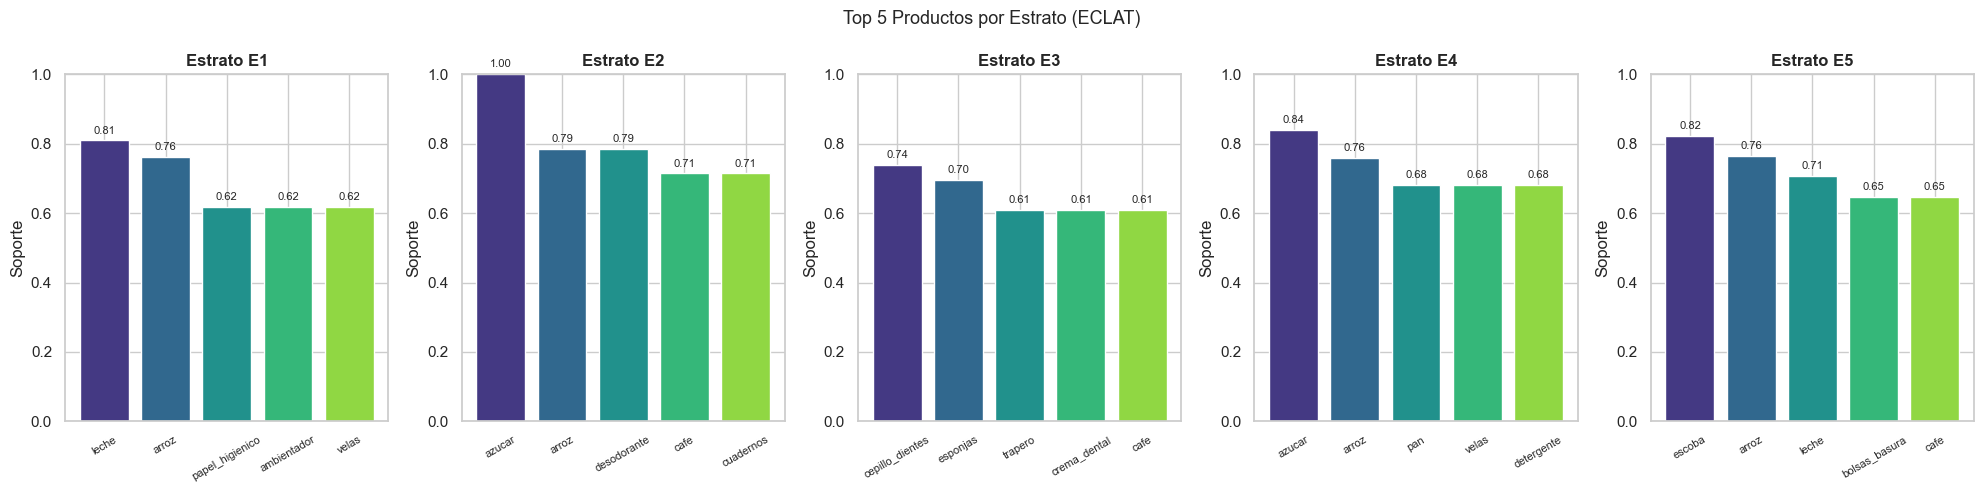

In [38]:
# --- Top 3 productos por estrato (barras agrupadas) ---
top3_estrato = {}
for estrato, res in resultados_estrato.items():
    singles = res[res['itemset'].apply(len) == 1].copy()
    singles['label'] = singles['itemset'].apply(lambda x: x[0])
    top3_estrato[estrato] = singles.sort_values('support', ascending=False).head(5)

fig, axes = plt.subplots(1, len(estratos), figsize=(4 * len(estratos), 5), sharey=False)
if len(estratos) == 1:
    axes = [axes]

for ax, estrato in zip(axes, estratos):
    data = top3_estrato[estrato]
    ax.bar(data['label'], data['support'],
           color=sns.color_palette('viridis', len(data)))
    ax.set_title(f'Estrato {estrato}', fontweight='bold')
    ax.set_ylim(0, 1)
    ax.set_ylabel('Soporte')
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    for i, (_, row) in enumerate(data.iterrows()):
        ax.text(i, row['support'] + 0.02, f"{row['support']:.2f}", ha='center', fontsize=8)

plt.suptitle('Top 5 Productos por Estrato (ECLAT)', fontsize=13)
plt.tight_layout()
plt.show()

---
## 6. Segmentación por Grupo de Edad

In [41]:
df['grupo_edad'] = pd.cut(
    df['edad'],
    bins=[0, 25, 35, 50, 100],
    labels=['Joven', 'Adulto joven', 'Adulto', 'Senior']
)

resultados_edad = {}
for grupo in ['Joven', 'Adulto joven', 'Adulto', 'Senior']:
    subset = df[df['grupo_edad'] == grupo]
    if len(subset) >= 5:
        resultados_edad[grupo] = eclat_segmento(subset)

print('Segmentación por grupo de edad completa.')

Segmentación por grupo de edad completa.


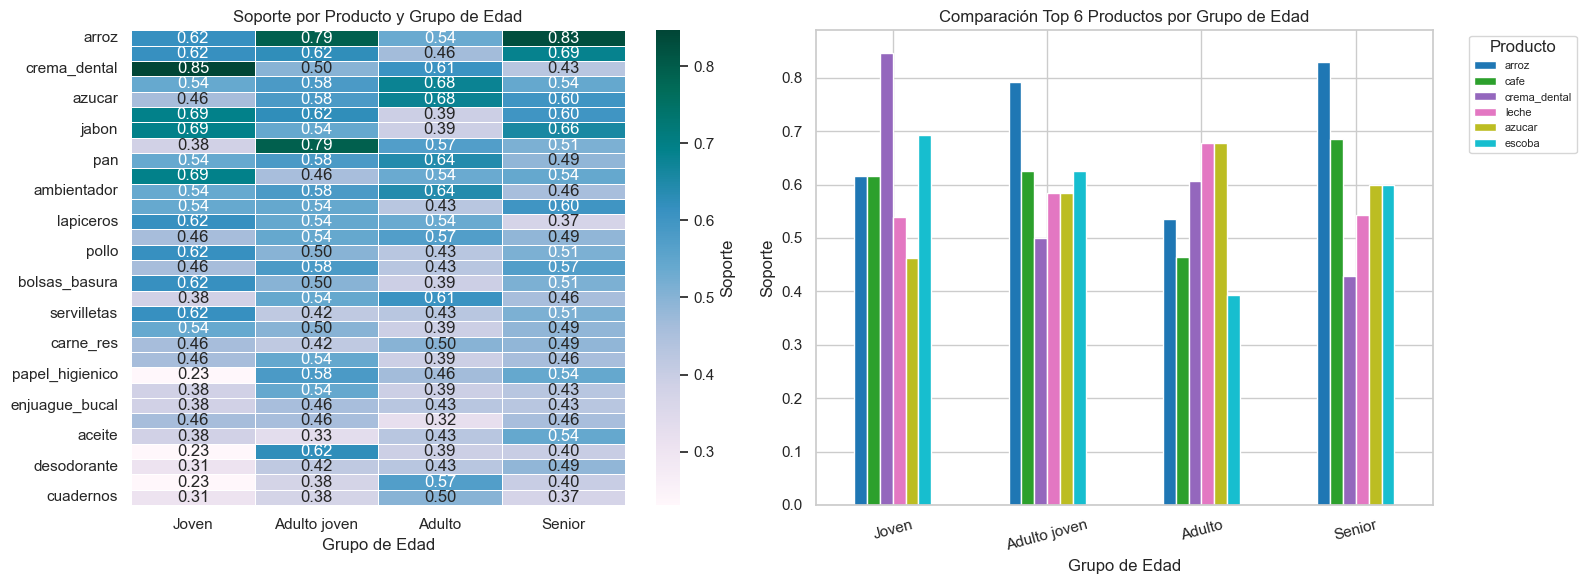

In [39]:
# --- Top productos por grupo de edad ---
data_edad = {}
for grupo, res in resultados_edad.items():
    singles = res[res['itemset'].apply(len) == 1]
    data_edad[grupo] = {row['itemset'][0]: row['support'] for _, row in singles.iterrows()}

heat_edad = pd.DataFrame(data_edad).fillna(0)
heat_edad = heat_edad.loc[heat_edad.mean(axis=1).sort_values(ascending=False).index]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap por edad
sns.heatmap(heat_edad, annot=True, fmt='.2f', cmap='PuBuGn',
            linewidths=0.5, ax=axes[0], cbar_kws={'label': 'Soporte'})
axes[0].set_title('Soporte por Producto y Grupo de Edad')
axes[0].set_xlabel('Grupo de Edad')

# Stacked bar por grupo de edad
top6 = heat_edad.mean(axis=1).nlargest(6).index.tolist()
heat_top = heat_edad.loc[top6]
heat_top.T.plot(kind='bar', ax=axes[1], colormap='tab10', edgecolor='white')
axes[1].set_title('Comparación Top 6 Productos por Grupo de Edad')
axes[1].set_ylabel('Soporte')
axes[1].set_xlabel('Grupo de Edad')
axes[1].legend(title='Producto', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

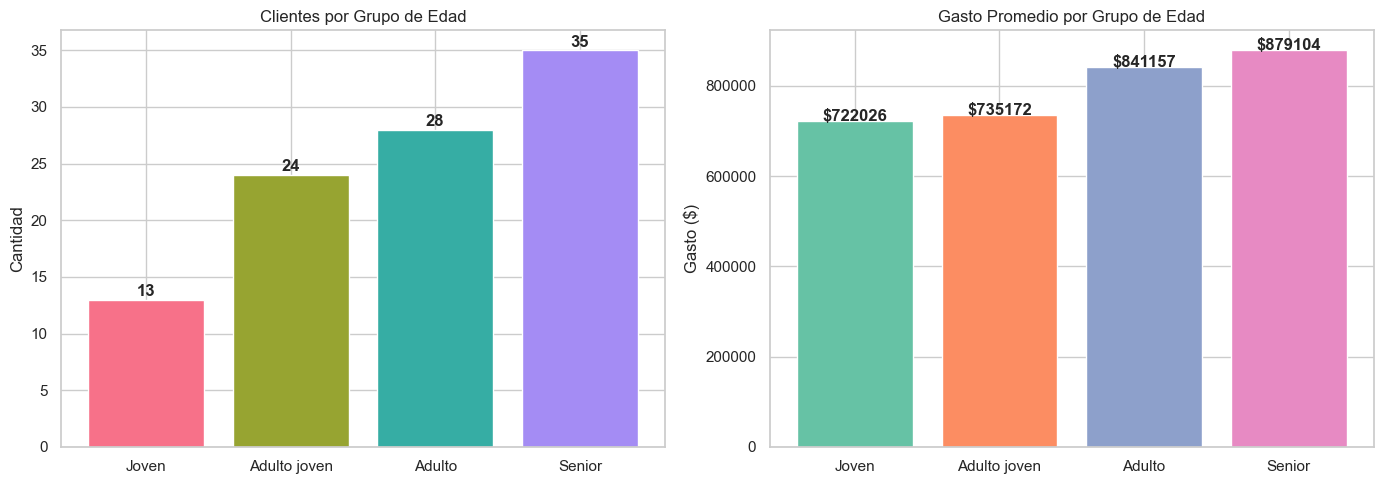

In [42]:
# --- Distribución de clientes por grupo de edad y estrato ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts_edad = df['grupo_edad'].value_counts().reindex(['Joven', 'Adulto joven', 'Adulto', 'Senior'])
axes[0].bar(counts_edad.index, counts_edad.values,
            color=sns.color_palette('husl', 4))
axes[0].set_title('Clientes por Grupo de Edad')
axes[0].set_ylabel('Cantidad')
for i, v in enumerate(counts_edad.values):
    axes[0].text(i, v + 0.3, str(v), ha='center', fontweight='bold')

# Distribución de edad y gasto por grupo
gasto_edad = df.groupby('grupo_edad', observed=True)['gasto'].mean().reindex(
    ['Joven', 'Adulto joven', 'Adulto', 'Senior'])
axes[1].bar(gasto_edad.index, gasto_edad.values,
            color=sns.color_palette('Set2', 4))
axes[1].set_title('Gasto Promedio por Grupo de Edad')
axes[1].set_ylabel('Gasto ($)')
for i, v in enumerate(gasto_edad.values):
    axes[1].text(i, v + 100, f'${v:.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

---
## 7. Red de Asociaciones

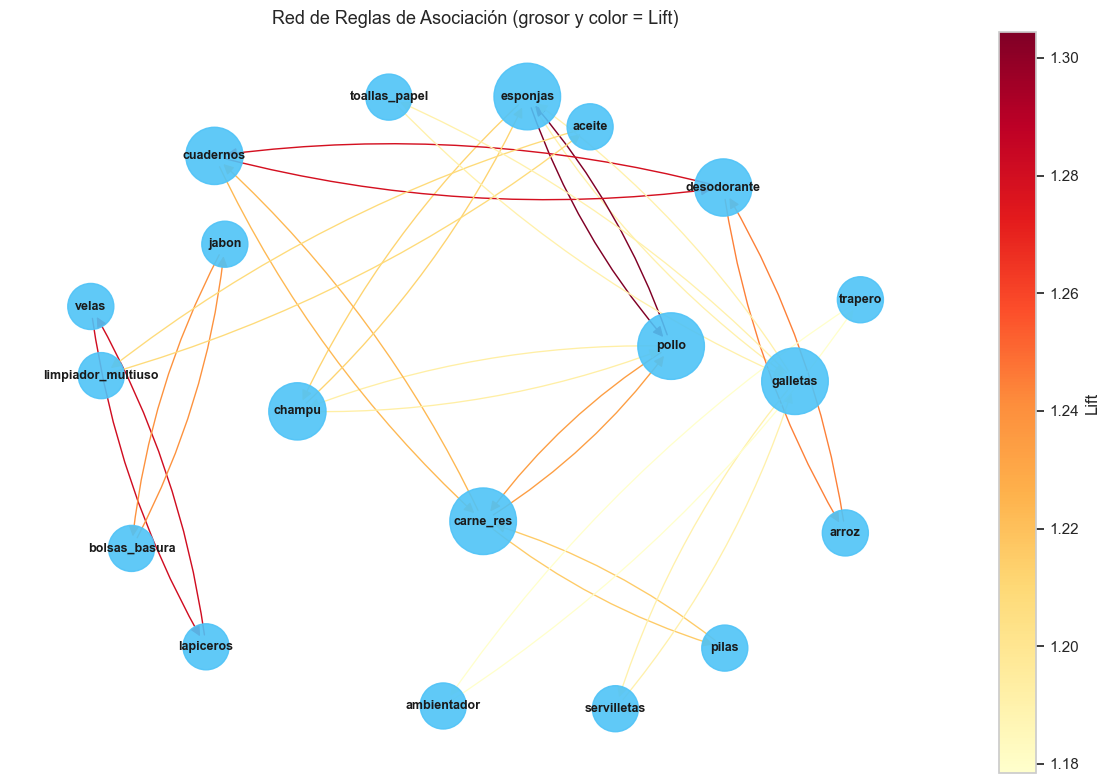

In [43]:
try:
    import networkx as nx
    top_net = rules[
        (rules['antecedents'].apply(len) == 1) &
        (rules['consequents'].apply(len) == 1)
    ].sort_values('lift', ascending=False).head(30)

    G = nx.DiGraph()
    for _, row in top_net.iterrows():
        ant = list(row['antecedents'])[0]
        con = list(row['consequents'])[0]
        G.add_edge(ant, con, weight=row['lift'], confidence=row['confidence'])

    pos = nx.spring_layout(G, seed=42, k=2)
    edge_weights = [G[u][v]['weight'] for u, v in G.edges()]
    node_sizes = [G.degree(n) * 300 + 500 for n in G.nodes()]

    fig, ax = plt.subplots(figsize=(12, 8))
    nx.draw_networkx_nodes(G, pos, node_size=node_sizes,
                           node_color='#4FC3F7', alpha=0.9, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold', ax=ax)
    nx.draw_networkx_edges(
        G, pos, edge_color=edge_weights, edge_cmap=plt.cm.YlOrRd,
        width=[w * 0.8 for w in edge_weights],
        arrows=True, arrowsize=15, connectionstyle='arc3,rad=0.1', ax=ax
    )
    sm = plt.cm.ScalarMappable(cmap=plt.cm.YlOrRd,
                                norm=plt.Normalize(min(edge_weights), max(edge_weights)))
    sm.set_array([])
    fig.colorbar(sm, ax=ax, label='Lift')
    ax.set_title('Red de Reglas de Asociación (grosor y color = Lift)', fontsize=13)
    ax.axis('off')
    plt.tight_layout()
    plt.show()
except ImportError:
    print('Instala networkx para el gráfico de red: pip install networkx')


---
## 8. Resumen Ejecutivo

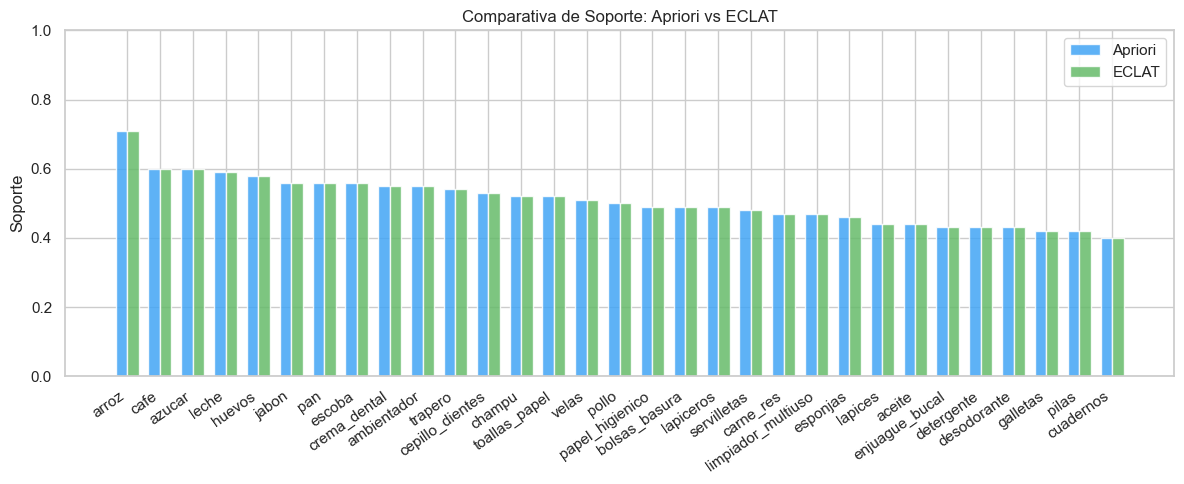


Los dos algoritmos deben coincidir en los valores de soporte (verificación):
             label  Apriori  ECLAT  diferencia
             arroz     0.71   0.71         0.0
              cafe     0.60   0.60         0.0
            azucar     0.60   0.60         0.0
             leche     0.59   0.59         0.0
            huevos     0.58   0.58         0.0
             jabon     0.56   0.56         0.0
               pan     0.56   0.56         0.0
            escoba     0.56   0.56         0.0
      crema_dental     0.55   0.55         0.0
       ambientador     0.55   0.55         0.0
           trapero     0.54   0.54         0.0
   cepillo_dientes     0.53   0.53         0.0
            champu     0.52   0.52         0.0
     toallas_papel     0.52   0.52         0.0
             velas     0.51   0.51         0.0
             pollo     0.50   0.50         0.0
   papel_higienico     0.49   0.49         0.0
     bolsas_basura     0.49   0.49         0.0
         lapiceros     0.49  

In [44]:
# --- Comparativa Apriori vs ECLAT (soporte de itemsets simples) ---
apriori_singles = frequent_itemsets[
    frequent_itemsets['itemsets'].apply(len) == 1
].copy()
apriori_singles['label'] = apriori_singles['itemsets'].apply(lambda x: list(x)[0])
apriori_singles = apriori_singles.sort_values('support', ascending=False)

eclat_singles = freq_df[freq_df['size'] == 1].copy()
eclat_singles['label'] = eclat_singles['itemset'].apply(lambda x: x[0])
eclat_singles = eclat_singles.sort_values('support', ascending=False)

compare = pd.merge(
    apriori_singles[['label', 'support']].rename(columns={'support': 'Apriori'}),
    eclat_singles[['label', 'support']].rename(columns={'support': 'ECLAT'}),
    on='label'
)

x = np.arange(len(compare))
width = 0.35
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, compare['Apriori'], width, label='Apriori', color='#42A5F5', alpha=0.85)
ax.bar(x + width/2, compare['ECLAT'], width, label='ECLAT', color='#66BB6A', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(compare['label'], rotation=35, ha='right')
ax.set_title('Comparativa de Soporte: Apriori vs ECLAT')
ax.set_ylabel('Soporte')
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()
print('\nLos dos algoritmos deben coincidir en los valores de soporte (verificación):')
compare['diferencia'] = (compare['Apriori'] - compare['ECLAT']).abs()
print(compare.to_string(index=False))

In [24]:
# --- Top 10 reglas finales recomendadas ---
print('=== TOP 10 REGLAS DE ASOCIACIÓN RECOMENDADAS ===')
top10 = rules.sort_values('score', ascending=False).head(10)[
    ['rule', 'support', 'confidence', 'lift', 'affinity', 'score']
].reset_index(drop=True)
top10.index += 1
print(top10.to_string())

=== TOP 10 REGLAS DE ASOCIACIÓN RECOMENDADAS ===
                                     rule  support  confidence      lift  affinity     score
1                     desodorante → arroz     0.38    0.883721  1.244677  1.099947  0.790519
2   limpiador_multiuso, pollo → carne_res     0.20    0.740741  1.576044  1.167440  0.775035
3                          huevos → arroz     0.47    0.810345  1.141331  0.924871  0.773503
4           champu, trapero → ambientador     0.24    0.800000  1.454545  1.163636  0.772364
5   carne_res, limpiador_multiuso → pollo     0.20    0.769231  1.538462  1.183432  0.772308
6                  cafe, esponjas → pollo     0.22    0.758621  1.517241  1.151011  0.770759
7       crema_dental, desodorante → arroz     0.25    0.925926  1.304121  1.207519  0.769014
8    desodorante, papel_higienico → arroz     0.20    0.952381  1.341382  1.277506  0.768129
9          desodorante, lapiceros → arroz     0.20    0.952381  1.341382  1.277506  0.768129
10            champu,